## Implementing a gradient descent algorithm

To become proficient with all three frameworks (NumPy,
JAX, PyTorch), I suggest to replicate the exercise below
thrice – each variant should only take a few minutes if you
know the syntax. Consider a 2D function $f(x), x \sim (2)$,
where we take the domain to be $[0, 10]$:

$$f(x) = sin(x_1) cos(x_2) + sin(0.5 x_1) cos(0.5 x_2)$$

Before proceeding in the book, repeat this for each
framework:

1. Implement the function in a **vectorized** way, i.e.,
given a matrix $X \sim (n, 2)$ of $n$ inputs, it should return
a vector $f(X) \sim (n)$ where $[f(X)]_i = f(X_i)$.
2. Implement another function to compute its gradient
(hard-coded – we have not touched automatic
differentiation yet).
3. Write a basic gradient descent procedure and
visualize the paths taken by the optimization process
from multiple starting points.
4. Try adding a momentum term and visualizing the
norm of the gradients, which should converge to
zero as the algorithm moves towards a stationary
point.
If you are using JAX or PyTorch to solve the exercise, point
(3) is a good place to experiment with `vmap` for vectorizing
a function.

In [1]:
 !uv pip install numpy matplotlib --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Vectorized function

In [3]:
def f(x: np.ndarray) -> np.ndarray:
    return np.sin(x[:, 0]) * np.cos(x[:, 1]) + np.sin(0.5 * x[:, 0]) * np.cos(0.5 * x[:, 1])

In [4]:
x = np.random.uniform(0, 10, size=(5,2))
print(f"x ~ {x.shape}; f(x) ~ {f(x).shape}")

x ~ (5, 2); f(x) ~ (5,)


## 2. Hard-coded gradient

In [5]:
def df(x: np.ndarray) -> np.ndarray:
    dx1 = np.cos(x[:, 0]) * np.cos(x[:, 1]) + 0.5 * np.cos(0.5 * x[:, 0]) * np.cos(0.5 * x[:, 1])
    dx2 = -np.sin(x[:, 0]) * np.sin(x[:, 1]) - 0.5 * np.sin(0.5 * x[:, 0]) * np.sin(0.5 * x[:, 1])
    return np.stack((dx1, dx2), axis=-1)

In [6]:
print(f"df(x) ~ {df(x).shape}")

df(x) ~ (5, 2)


## Plots

In [7]:
x1 = np.linspace(0, 10, 101)
x2 = np.linspace(0, 10, 101)
X1, X2 = np.meshgrid(x1, x2, indexing='xy')
X = np.column_stack([X1.ravel(), X2.ravel()])

In [8]:
y = f(X)  # (10000,)
Y = y.reshape(101, 101)  # back to grid

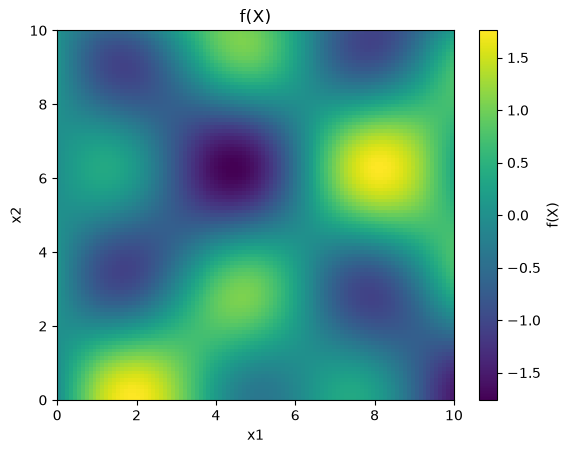

In [9]:
# 2D heatmap
plt.figure()
plt.imshow(Y, origin='lower', extent=[x1.min(), x1.max(), x2.min(), x2.max()],
           aspect='auto')
plt.colorbar(label='f(X)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('f(X)')
plt.show()

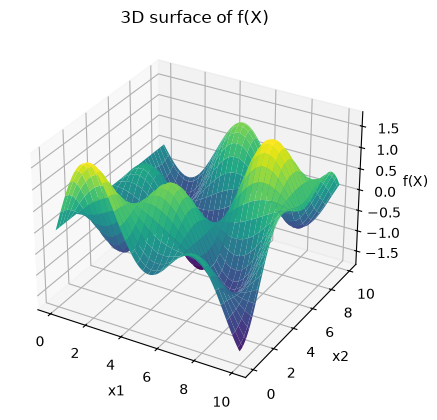

In [10]:
# 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X1, X2, Y, cmap='viridis', edgecolor='none')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(X)')
plt.title('3D surface of f(X)')
plt.show()

## 3. Gradient descent

$$x_t = x_{t-1} - \eta_t \nabla f(x_{t-1})$$

In [11]:
learning_rate = 1e-3
points = 10  # starting points
steps = 500

x_0 = np.random.uniform(0, 10, size=(points, 2))

In [12]:
x_history = [x_0.copy()]
x = x_0.copy()

for _ in range(steps):
    x = x - learning_rate * df(x)
    x_history.append(x.copy())

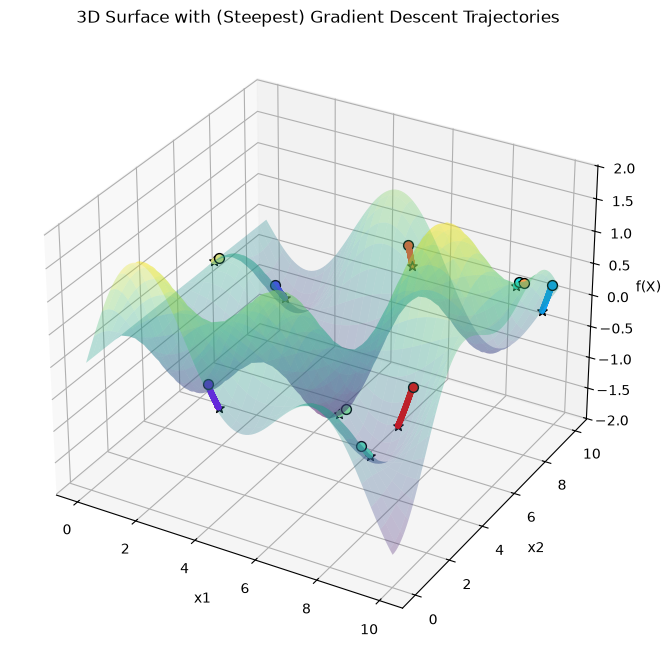

In [13]:
# Convert to array for easier indexing
x_history = np.array(x_history)  # Shape: (steps+1, points, 2)

# 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
ax.plot_surface(X1, X2, Y, cmap='viridis', edgecolor='none', alpha=0.3)

# Plot trajectories
colors = plt.cm.rainbow(np.linspace(0, 1, points))

for i in range(points):
    traj_x1 = x_history[:, i, 0]  # x1 coordinates over time
    traj_x2 = x_history[:, i, 1]  # x2 coordinates over time

    # Compute f values for all points in trajectory at once
    traj_points = np.column_stack([traj_x1, traj_x2])
    traj_y = f(traj_points)
    
    # Plot all points along the trajectory
    ax.scatter(traj_x1, traj_x2, traj_y, color=colors[i], s=10, alpha=0.6)
    
    # Mark starting point
    ax.scatter(traj_x1[0], traj_x2[0], traj_y[0], color=colors[i], s=50,
               marker='o', edgecolor='black', linewidth=1)
    
    # Mark ending point
    ax.scatter(traj_x1[-1], traj_x2[-1], traj_y[-1], color=colors[i], s=50,
               marker='*', edgecolor='black', linewidth=1)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(X)')
ax.set_title('3D Surface with (Steepest) Gradient Descent Trajectories')
plt.show()

## 4. Gradient descent with momentum

$$g_t = -\eta_t \nabla f(x_{t-1}) + \lambda g_{t-1}$$
$$x_t = x_{t-1} + g_t$$

In [14]:
learning_rate = 1e-3
momentum = 0.9
points = 10  # starting points
steps = 5000

x_0 = np.random.uniform(0, 10, size=(points, 2))

In [15]:
x_history = [x_0.copy()]
x = x_0.copy()
g = 0

for _ in range(steps):
    g = -learning_rate * df(x) + momentum * g
    x = x + g
    x_history.append(x.copy())

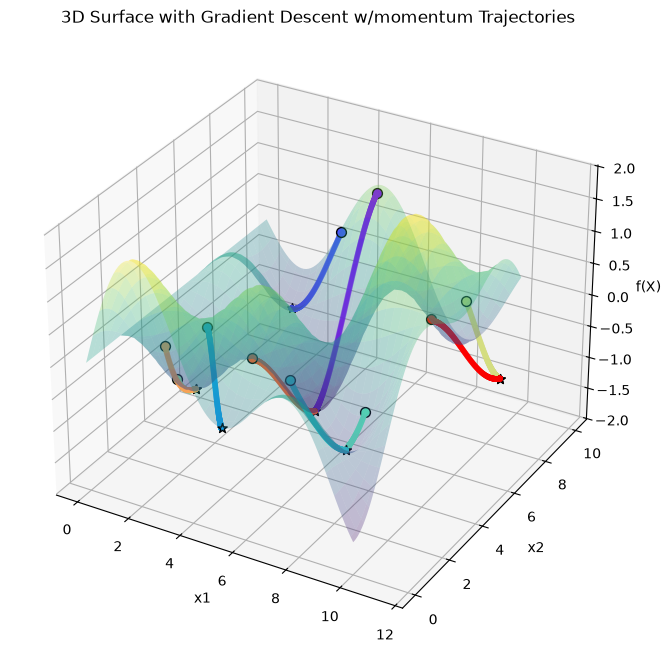

In [16]:
# Convert to array for easier indexing
x_history = np.array(x_history)  # Shape: (steps+1, points, 2)

# 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
ax.plot_surface(X1, X2, Y, cmap='viridis', edgecolor='none', alpha=0.3)

# Plot trajectories
colors = plt.cm.rainbow(np.linspace(0, 1, points))

for i in range(points):
    traj_x1 = x_history[:, i, 0]  # x1 coordinates over time
    traj_x2 = x_history[:, i, 1]  # x2 coordinates over time

    # Compute f values for all points in trajectory at once
    traj_points = np.column_stack([traj_x1, traj_x2])
    traj_y = f(traj_points)
    
    # Plot all points along the trajectory
    ax.scatter(traj_x1, traj_x2, traj_y, color=colors[i], s=10, alpha=0.6)
    
    # Mark starting point
    ax.scatter(traj_x1[0], traj_x2[0], traj_y[0], color=colors[i], s=50,
               marker='o', edgecolor='black', linewidth=1)
    
    # Mark ending point
    ax.scatter(traj_x1[-1], traj_x2[-1], traj_y[-1], color=colors[i], s=50,
               marker='*', edgecolor='black', linewidth=1)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(X)')
ax.set_title('3D Surface with Gradient Descent w/momentum Trajectories')
plt.show()

In [17]:
# EOF